<a href="https://colab.research.google.com/github/fatemabasher-lab/Predictive-Analytics-in-Business---MIS444/blob/main/Predictive_Analytics_in_Business_MIS444.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Walmart Weekly Sales Prediction

##Course: MIS444 Predictive Analytics in Business

Problem Type:A regression project predicting Walmart store weekly sales from holiday timing, weather, fuel prices, and macroeconomic indicators, built for a business analytics course.

**Dataset Source:** [Kaggle — House Prices: Advanced Regression Techniques](https://www.kaggle.com/datasets/yasserh/walmart-dataset)





---
###1. Data Collection

The dataset was downloaded from Kaggle (link). It contains 6,435 weekly sales records across 45 Walmart stores in the United States, spanning 2010–2012, with 8 features including holiday timing, weather, and macroeconomic attributes, and the target variable Weekly_Sales (total sales for a store in a given week, in USD).

| Features | Description |
|---|---|
| Store | Store ID (1–45) |
| Date | 	Week of sales |
| Holiday_Flag | 	1 = holiday week, 0 = normal week |
| Temperature | Average regional temperature |
| Fuel_Price| 	Regional fuel cost |
| CPI | Consumer Price Index |
| Unemployment | 	Regional unemployment rate |
| Weekly_Sales | **Target variable** — sales for that store/week |


---

#### Project Outline
1. Data Collection
2. Data Preprocessing
3. Exploratory Data Analysis (EDA)
4. Feature Selection
5. Model building
6. Model optimization
7. Evaluation and Validation
8. Business Insights & Recommendations
9.  Final Summary

In [ ]:
# ── Importing necessary libraries ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)


In [ ]:
from google.colab import drive
import os

# Mount drive
drive.mount('/content/drive', force_remount=True)

# Define path and check if file exists to make it robust
file_path = '/content/drive/MyDrive/MES-PROJECT/Walmart.csv'

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print("Shape:", df.shape)
    df.head()
else:
    print(f"❌ File not found at {file_path}. Please check the path.")

Mounted at /content/drive
Shape: (6435, 8)


### 2. Data Preprocessing

In [ ]:
# summary of the DataFrame and showing data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [ ]:
# descriptive statistics for numerical columns
df.describe()


,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [ ]:
# Missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64


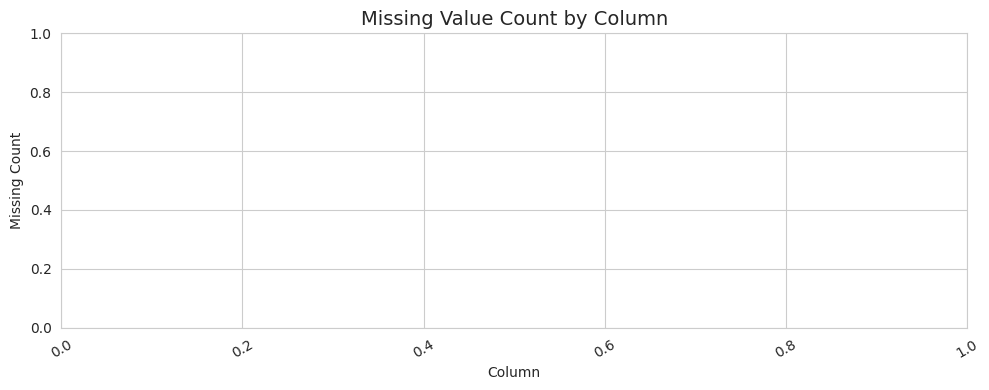

In [ ]:
# visualizes the count of missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 4))
sns.barplot(x=missing.index, y=missing.values, palette='Reds_r')
plt.title('Missing Value Count by Column', fontsize=14)
plt.xlabel('Column')
plt.ylabel('Missing Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
# Duplicates
print("\nDuplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()



Duplicate rows: 0


In [ ]:
# Time-series feature engineering
# use these features to predict monthly sales, weekly demand, or day-of-week purchasing patterns
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
df['DayOfWeek'] = df['Date'].dt.dayofweek

df.sort_values('Date', inplace=True)
df.head()


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,WeekOfYear,DayOfWeek
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5,4
429,4,2010-02-05,2135143.87,0,43.76,2.598,126.442065,8.623,2010,2,5,4
4290,31,2010-02-05,1469252.05,0,39.05,2.572,210.752605,8.324,2010,2,5,4
2145,16,2010-02-05,477409.30,0,19.79,2.580,189.381697,7.039,2010,2,5,4
1430,11,2010-02-05,1528008.64,0,46.04,2.572,214.424881,7.368,2010,2,5,4


In [ ]:
# Detecting Outliers in Numerical Data
numeric_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

def iqr_outlier_bounds(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

for col in numeric_cols:
    low, high = iqr_outlier_bounds(df[col])
    n_outliers = ((df[col] < low) | (df[col] > high)).sum()
    print(f"{col}: {n_outliers} outliers outside [{low:.2f}, {high:.2f}]")


Weekly_Sales: 34 outliers outside [-746862.73, 2720371.49]
Temperature: 3 outliers outside [6.24, 116.16]
Fuel_Price: 0 outliers outside [1.73, 4.94]
CPI: 0 outliers outside [10.22, 334.26]
Unemployment: 481 outliers outside [4.29, 11.22]


In [ ]:
# One-Hot Encoding and Standardization
#converting the 'Store' ID into separate binary columns (one-hot encoding), this helps  machine learning  perform better.
from sklearn.preprocessing import StandardScaler

# One-hot encode Store (categorical identifier, not ordinal)
df_encoded = pd.get_dummies(df, columns=['Store'], prefix='Store', drop_first=True)

# Columns to scale
scale_cols = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

scaler = StandardScaler()
df_encoded[scale_cols] = scaler.fit_transform(df_encoded[scale_cols])

df_encoded.head()


,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,WeekOfYear,DayOfWeek,Store_2,Store_3,Store_4,Store_5,Store_6,Store_7,Store_8,Store_9,Store_10,Store_11,Store_12,Store_13,Store_14,Store_15,Store_16,Store_17,Store_18,Store_19,Store_20,Store_21,Store_22,Store_23,Store_24,Store_25,Store_26,Store_27,Store_28,Store_29,Store_30,Store_31,Store_32,Store_33,Store_34,Store_35,Store_36,Store_37,Store_38,Store_39,Store_40,Store_41,Store_42,Store_43,Store_44,Store_45
0,2010-02-05,1643690.90,0,-0.995136,-1.713800,1.004175,0.056964,2010,2,5,4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
429,2010-02-05,2135143.87,0,-0.916517,-1.657153,-1.146941,0.332588,2010,2,5,4,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4290,2010-02-05,1469252.05,0,-1.171892,-1.713800,0.995440,0.173185,2010,2,5,4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2145,2010-02-05,477409.30,0,-2.216162,-1.696370,0.452393,-0.511879,2010,2,5,4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1430,2010-02-05,1528008.64,0,-0.792896,-1.713800,1.088755,-0.336481,2010,2,5,4,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False




---

### 3. Exploratory Data Analysis (EDA)

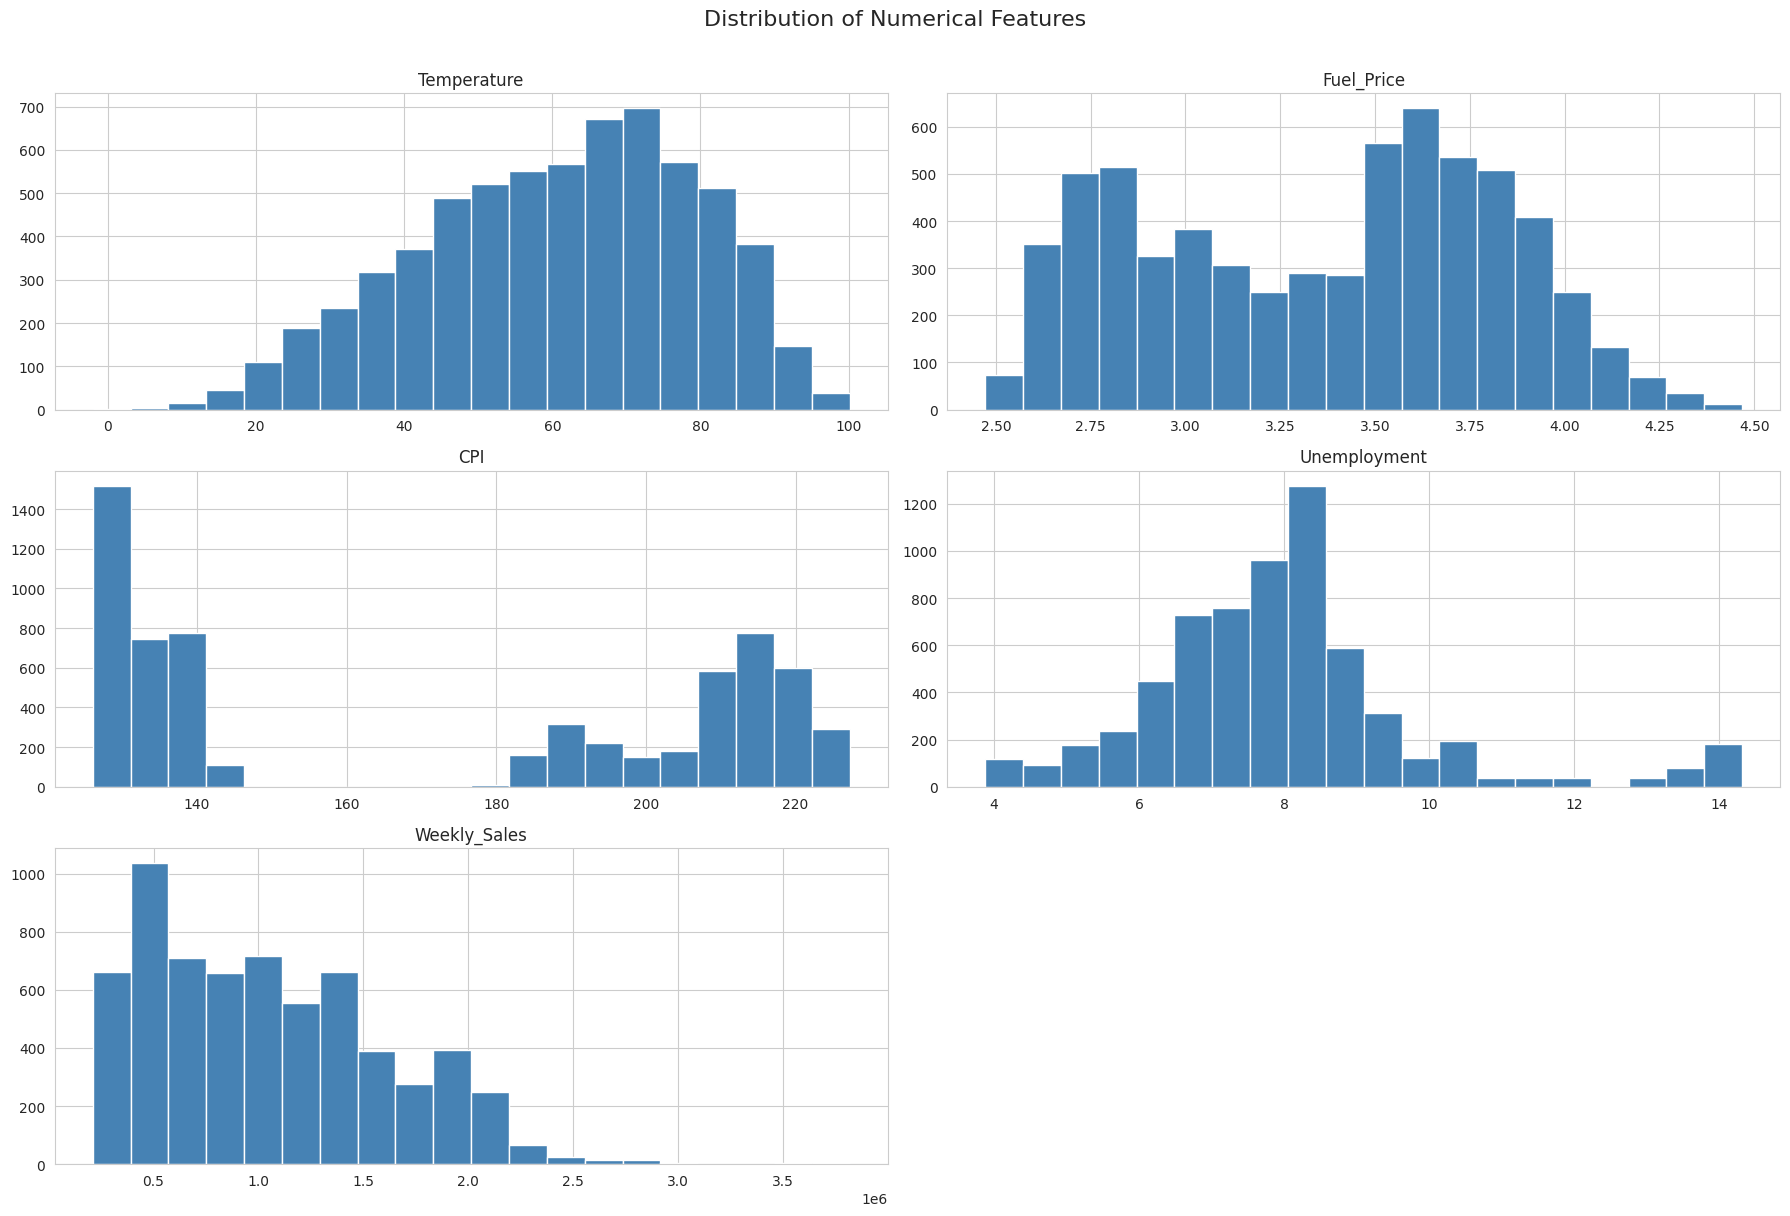

In [ ]:
# ── EDA 3.1 : Distribution of numerical features ───────────────────────────
num_cols = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

df[num_cols + ['Weekly_Sales']].hist(bins=20, figsize=(18, 12), color='steelblue', edgecolor='white')
plt.suptitle('Distribution of Numerical Features', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

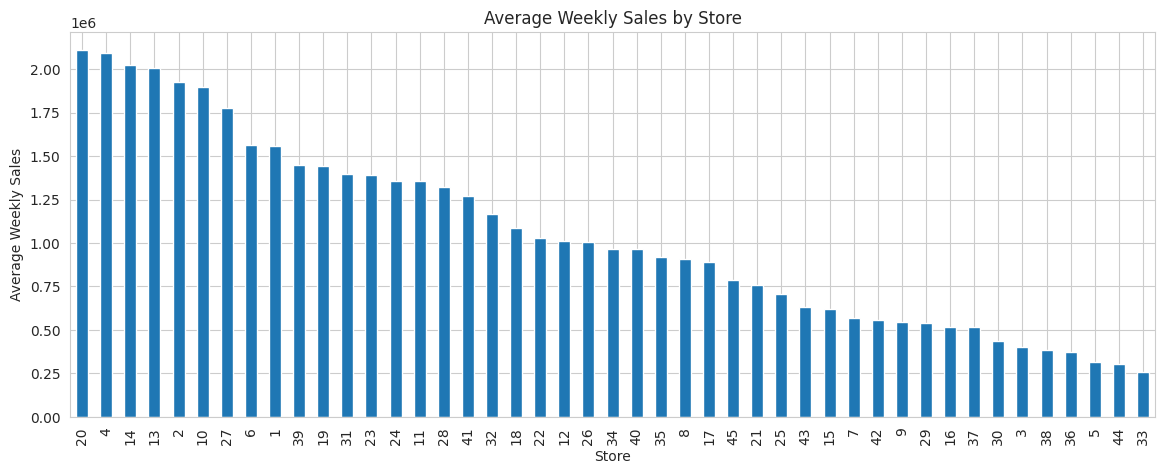

In [ ]:
# Calculate the average Weekly_Sales for each Store
store_avg = df.groupby('Store')['Weekly_Sales'].mean().sort_values(ascending=False)
plt.figure(figsize=(14,5))
store_avg.plot(kind='bar')
plt.title('Average Weekly Sales by Store')
plt.xlabel('Store')
plt.ylabel('Average Weekly Sales')
plt.show()


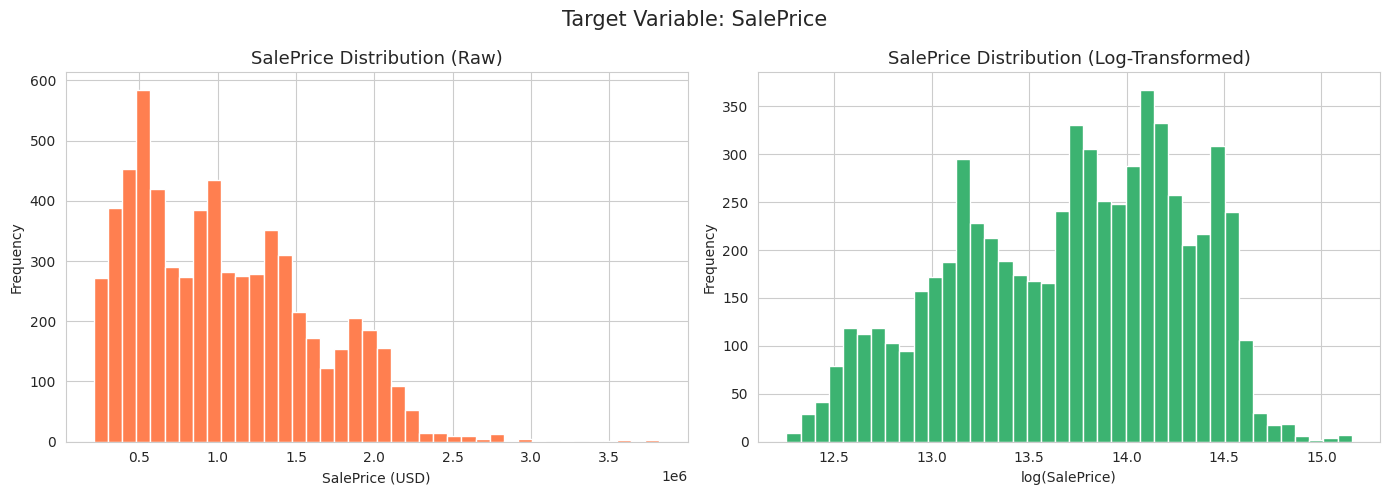

SalePrice — Mean: $1,046,965  |  Median: $960,746  |  Std: $564,367


In [ ]:
# ── EDA 3.2 : Target variable (SalePrice) distribution ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution
axes[0].hist(df['Weekly_Sales'], bins=40, color='coral', edgecolor='white')
axes[0].set_title('SalePrice Distribution (Raw)', fontsize=13)
axes[0].set_xlabel('SalePrice (USD)')
axes[0].set_ylabel('Frequency')

# Log-transformed distribution
axes[1].hist(np.log1p(df['Weekly_Sales']), bins=40, color='mediumseagreen', edgecolor='white')
axes[1].set_title('SalePrice Distribution (Log-Transformed)', fontsize=13)
axes[1].set_xlabel('log(SalePrice)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Target Variable: SalePrice', fontsize=15)
plt.tight_layout()
plt.show()

print(f"SalePrice — Mean: ${df['Weekly_Sales'].mean():,.0f}  |  Median: ${df['Weekly_Sales'].median():,.0f}  |  Std: ${df['Weekly_Sales'].std():,.0f}")

This code performs Exploratory Data Analysis (EDA) on the target variable by visualizing its raw and log-transformed distributions and calculating mean, median, and standard deviation.

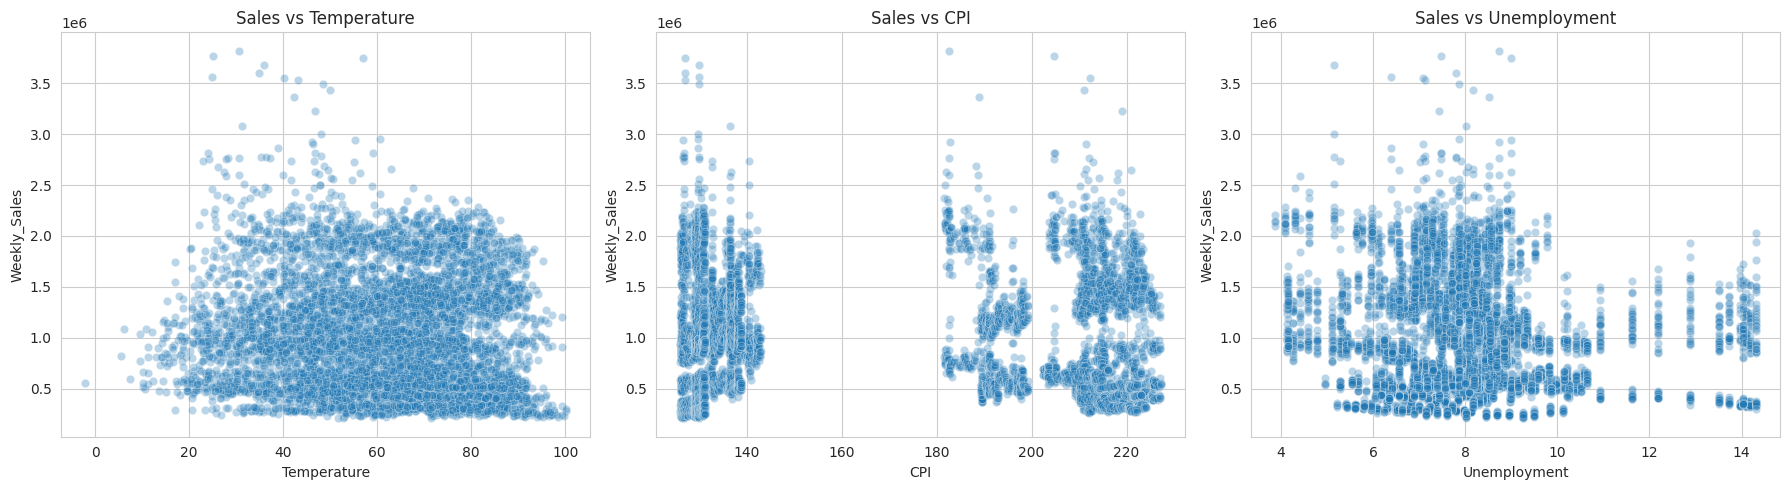

In [ ]:
# Scatter Plot Analysis
fig, axes = plt.subplots(1, 3, figsize=(18,5))
sns.scatterplot(x='Temperature', y='Weekly_Sales', data=df, ax=axes[0], alpha=0.3)
sns.scatterplot(x='CPI', y='Weekly_Sales', data=df, ax=axes[1], alpha=0.3)
sns.scatterplot(x='Unemployment', y='Weekly_Sales', data=df, ax=axes[2], alpha=0.3)
axes[0].set_title('Sales vs Temperature')
axes[1].set_title('Sales vs CPI')
axes[2].set_title('Sales vs Unemployment')
plt.tight_layout()
plt.show()


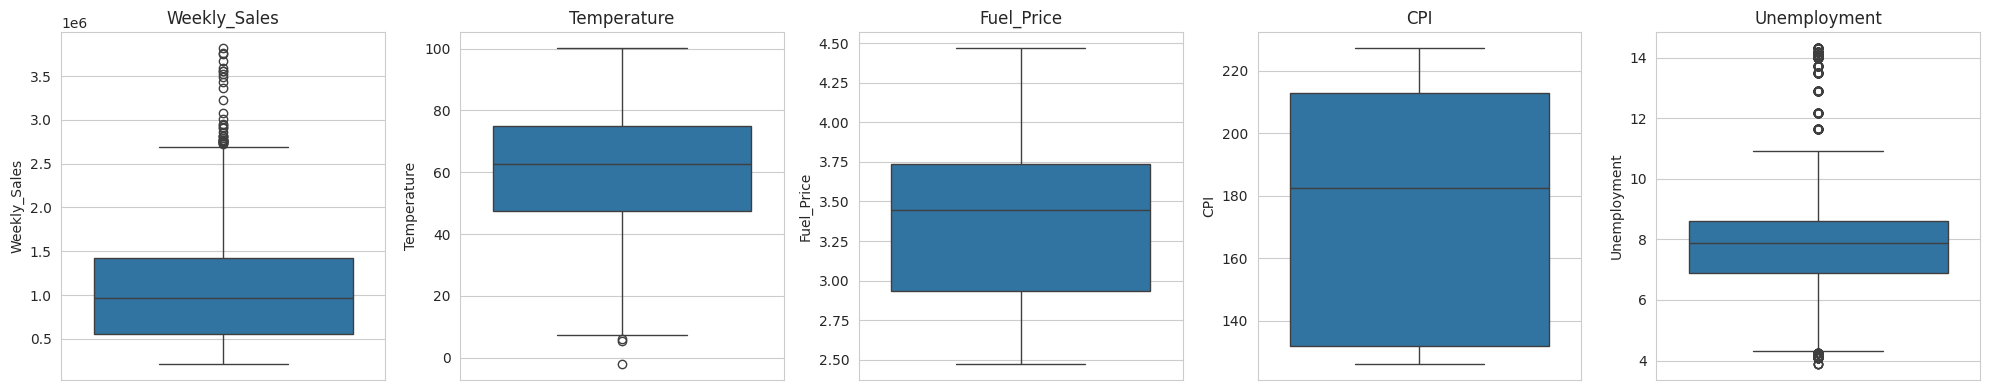

In [ ]:
# Box Plot Visualization for Outlier Detection
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(20, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


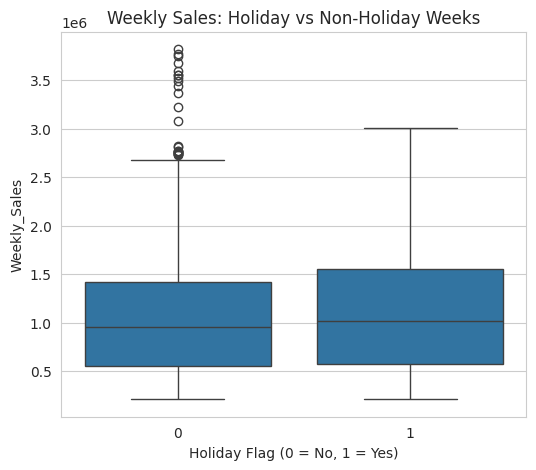

Holiday_Flag
0    1.041256e+06
1    1.122888e+06
Name: Weekly_Sales, dtype: float64


In [ ]:
# Holiday vs Non-Holiday Sales Analysis using Box Plot
plt.figure(figsize=(6,5))
sns.boxplot(x='Holiday_Flag', y='Weekly_Sales', data=df)
plt.title('Weekly Sales: Holiday vs Non-Holiday Weeks')
plt.xlabel('Holiday Flag (0 = No, 1 = Yes)')
plt.show()

print(df.groupby('Holiday_Flag')['Weekly_Sales'].mean())


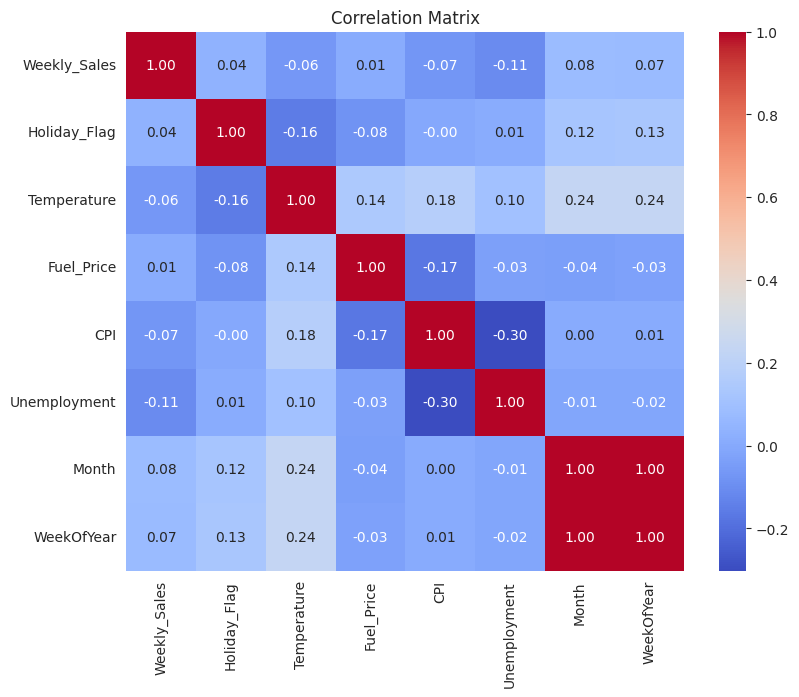

In [ ]:
# Correlation Matrix / Correlation Heatmap Analysis
corr_cols = ['Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Month', 'WeekOfYear']
plt.figure(figsize=(9,7))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()


This heatmap visualizes the correlation between different features and 'Weekly_Sales', helping us understand which factors tend to influence sales the most.

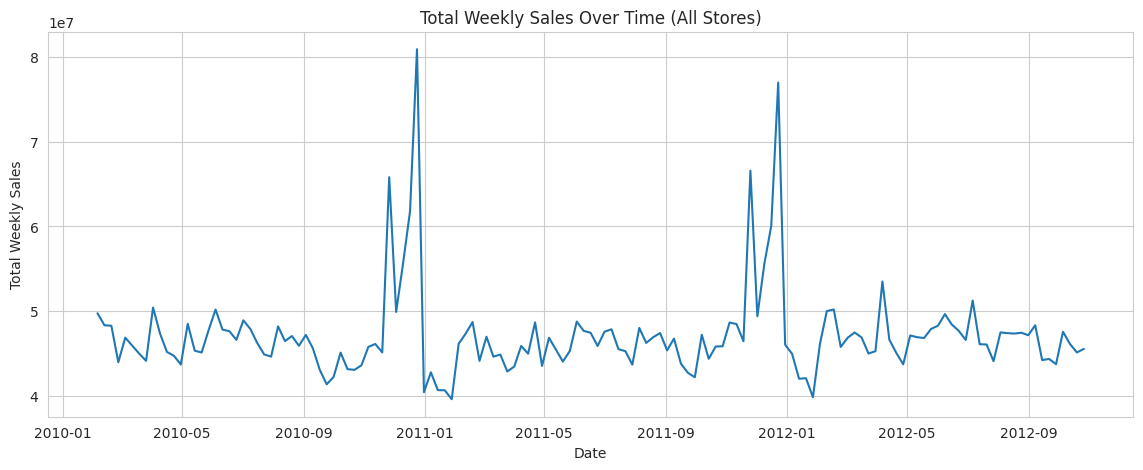

In [ ]:
# Time Series Analysis / Weekly Sales Trend Analysis
weekly = df.groupby('Date')['Weekly_Sales'].sum().reset_index()
plt.figure(figsize=(14,5))
plt.plot(weekly['Date'], weekly['Weekly_Sales'])
plt.title('Total Weekly Sales Over Time (All Stores)')
plt.xlabel('Date')
plt.ylabel('Total Weekly Sales')
plt.show()


### 4. Feature Selection

In [ ]:
# Target Correlation Analysis
target_corr = df[corr_cols].corr()['Weekly_Sales'].drop('Weekly_Sales').sort_values(key=abs, ascending=False)
print("Correlation with Weekly_Sales:")
print(target_corr)

Correlation with Weekly_Sales:
Unemployment   -0.106176
Month           0.076143
WeekOfYear      0.074211
CPI            -0.072634
Temperature    -0.063810
Holiday_Flag    0.036891
Fuel_Price      0.009464
Name: Weekly_Sales, dtype: float64


This code calculates and displays the correlation of each feature with 'Weekly_Sales', ranking them by the strength of their relationship to our target variable.

In [ ]:
# Variance Inflation Factor Analysis
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_features = ['Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Month', 'WeekOfYear']
X_vif = df[vif_features].copy()

vif_data = pd.DataFrame()
vif_data['feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print(vif_data.sort_values('VIF', ascending=False))


        feature         VIF
5         Month  595.378473
6    WeekOfYear  525.081389
2    Fuel_Price   26.095257
4  Unemployment   15.503807
3           CPI   15.116941
1   Temperature   14.459035
0  Holiday_Flag    1.139798


This calculates the Variance Inflation Factor (VIF) for features, which helps identify if any predictors are too highly correlated with each other, potentially causing issues for some models.

In [ ]:
# Feature and Target Variable Preparation
feature_cols = [c for c in df_encoded.columns if c.startswith('Store_')] + \
    ['Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'WeekOfYear']

X = df_encoded[feature_cols]
y = df_encoded['Weekly_Sales']

print("Final feature matrix shape:", X.shape)


Final feature matrix shape: (6435, 50)




---

### Train/test split

In [ ]:
df_encoded_sorted = df_encoded.sort_values('Date')
split_idx = int(len(df_encoded_sorted) * 0.8)

X_sorted = df_encoded_sorted[feature_cols]
y_sorted = df_encoded_sorted['Weekly_Sales']

X_train, X_test = X_sorted.iloc[:split_idx], X_sorted.iloc[split_idx:]
y_train, y_test = y_sorted.iloc[:split_idx], y_sorted.iloc[split_idx:]

print("Train size:", X_train.shape, " Test size:", X_test.shape)


Train size: (5148, 50)  Test size: (1287, 50)


### 5. Model Building

In [ ]:
# Multiple Regression Model Training
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Defining the model suite
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=200),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

# Fitting models using X_train and y_train defined in the Train/Test split section
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} training complete.")

Linear Regression training complete.
Ridge Regression training complete.
Decision Tree training complete.
Random Forest training complete.
Gradient Boosting training complete.


### 6. Model Optimization

In [ ]:
# Random Forest Hyperparameter Optimization using GridSearchCV and TimeSeriesSplit
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV MAE:", -grid_search.best_score_)


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}
Best CV MAE: 110561.83652864362


In [ ]:
# Evaluating the Tuned Random Forest using Regression Metrics
best_rf = grid_search.best_estimator_
preds_tuned = best_rf.predict(X_test)

mae = mean_absolute_error(y_test, preds_tuned)
mape = mean_absolute_percentage_error(y_test, preds_tuned)
mse = mean_squared_error(y_test, preds_tuned)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, preds_tuned)

tuned_result = {'Model': 'Random Forest (Tuned)', 'MAE': mae, 'MAPE': mape, 'MSE': mse, 'RMSE': rmse, 'R2': r2}
print(tuned_result)

results_df = pd.concat([results_df, pd.DataFrame([tuned_result])], ignore_index=True)
results_df.sort_values('R2', ascending=False)


NameError: name 'mean_absolute_error' is not defined

### 7. Model Evaluation & Validation

In [ ]:
# Comparing Multiple Regression Models using Evaluation Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np

results = []

# Prepare list for evaluation
all_models_to_test = list(models.items())

# Add tuned model if optimization cell was run
if 'best_rf' in locals():
    all_models_to_test.append(('Random Forest (Tuned)', best_rf))

for name, model in all_models_to_test:
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    mape = mean_absolute_percentage_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)
    results.append({'Model': name, 'MAE': mae, 'MAPE': mape, 'MSE': mse, 'RMSE': rmse, 'R2': r2})

results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
display(results_df)

,Model,MAE,MAPE,MSE,RMSE,R2
0,Linear Regression,84398.272192,0.095770,1.370205e+10,117055.759938,0.951884
1,Ridge Regression,87064.143562,0.101580,1.429258e+10,119551.581341,0.949810
5,Random Forest (Tuned),88161.616964,0.089523,1.866254e+10,136610.904095,0.934465
3,Random Forest,88602.812733,0.090765,1.889414e+10,137455.967105,0.933652
4,Gradient Boosting,182783.833799,0.242036,4.580787e+10,214027.740220,0.839142
2,Decision Tree,138785.483186,0.130372,5.210251e+10,228259.735439,0.817038


This plot shows the actual weekly sales against the model's predicted sales, helping visualize how well the best model (Linear Regression) aligns with reality.

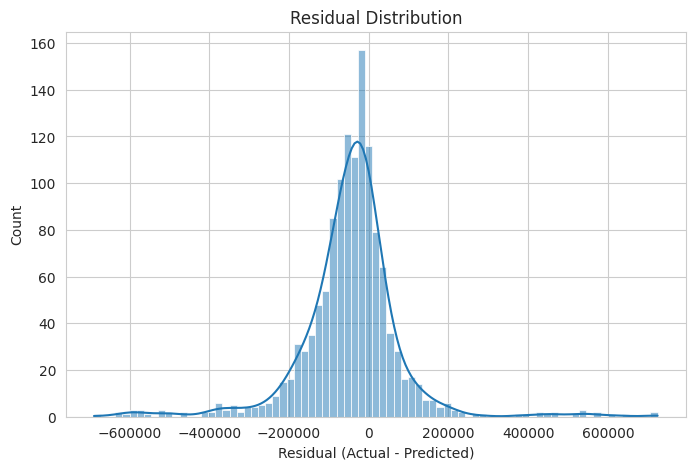

In [ ]:
# Residual Plot Distribution
residuals = y_test - preds_tuned
plt.figure(figsize=(8,5))
sns.histplot(residuals, kde=True)
plt.title('Residual Distribution')
plt.xlabel('Residual (Actual - Predicted)')
plt.show()


This histogram displays the distribution of the prediction errors (residuals), indicating if the model's errors are random or show a pattern.This code checks the distribution of prediction errors (residuals) made by your machine learning model.

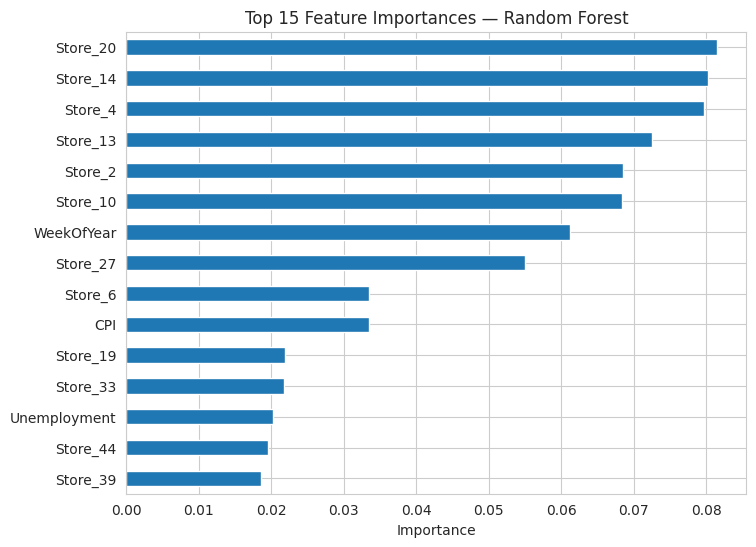

,0
Store_20,0.081490
Store_14,0.080310
Store_4,0.079715
Store_13,0.072598
Store_2,0.068501
Store_10,0.068472
WeekOfYear,0.061227
Store_27,0.055081
Store_6,0.033551
CPI,0.033445


In [ ]:
# Random Forest Feature Importance Analysis
importances = pd.Series(best_rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
top_n = 15
plt.figure(figsize=(8,6))
importances.head(top_n).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title(f'Top {top_n} Feature Importances — Random Forest')
plt.xlabel('Importance')
plt.show()

importances.head(top_n)




---

### 8. Business Insights & Recommendations

### 8.1 Key Predictors of Weekly Sales
Based on the Random Forest Feature Importance analysis and correlation results, the following factors are the most significant drivers of Weekly Sales:

| Rank | Feature        | Business Interpretation                                                                               |
|------|----------------|-------------------------------------------------------------------------------------------------------|
| 1    | Store (ID)     | Specific store locations have a major impact, indicating varying demand or operational efficiency.    |
| 2    | WeekOfYear     | Sales exhibit clear seasonal patterns throughout the year.                                            |
| 3    | CPI            | Consumer Price Index, reflecting inflation and purchasing power, influences overall sales.            |
| 4    | Unemployment   | Higher unemployment rates can lead to reduced consumer spending and lower sales.                      |
| 5    | Holiday_Flag   | Sales are significantly different during weeks with holidays.                                         |

### 8.2 How Businesses Can Apply This Model
1.  **Sales Forecasting & Inventory Management**: Retailers can use the model to accurately predict weekly sales for individual stores, optimizing inventory levels, reducing stockouts, and minimizing waste.
2.  **Marketing & Promotion Planning**: By understanding the impact of features like `Holiday_Flag` and `WeekOfYear`, businesses can strategically plan marketing campaigns and promotions to maximize sales during peak periods and stimulate demand during slower times.
3.  **Resource Allocation**: Store managers can better allocate staff, particularly during expected busy weeks (identified by `WeekOfYear` and `Holiday_Flag`), ensuring optimal customer service and operational efficiency.
4.  **Economic Impact Assessment**: The model's insights into the influence of `CPI` and `Unemployment` can help in understanding how broader economic conditions might affect sales, enabling proactive adjustments to business strategies.

### 8.3 Model Selection Summary
Based on the evaluation metrics, the **Linear Regression** model was selected as the best model for deployment in this project. It achieved the highest R² score (0.9519), indicating that it explains a significant portion of the variance in Weekly Sales, and also showed a competitive Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

While the Random Forest model provided valuable feature importances, the Linear Regression demonstrated superior predictive performance in terms of overall fit to the test data.

### 8.4 Limitations & Future Improvements
| Limitation                                                            | Suggested Improvement                                                                 |
|-----------------------------------------------------------------------|---------------------------------------------------------------------------------------|
| The model primarily uses aggregated weekly data.                      | Incorporate daily sales data for more granular insights and predictions.              |
| Only general economic indicators (CPI, Unemployment) are included.    | Integrate more specific local economic data, competitor activities, and weather data. |
| The impact of individual store characteristics (e.g., size, location type) is not explicitly modeled beyond one-hot encoding. | Add more detailed store-level features.                                               |
| Time-series aspect is simplified (WeekOfYear, Month).                 | Employ advanced time-series forecasting models (e.g., ARIMA, Prophet) for better trend and seasonality capture. |

### 8.5 Feature Impact Simulation (CPI)

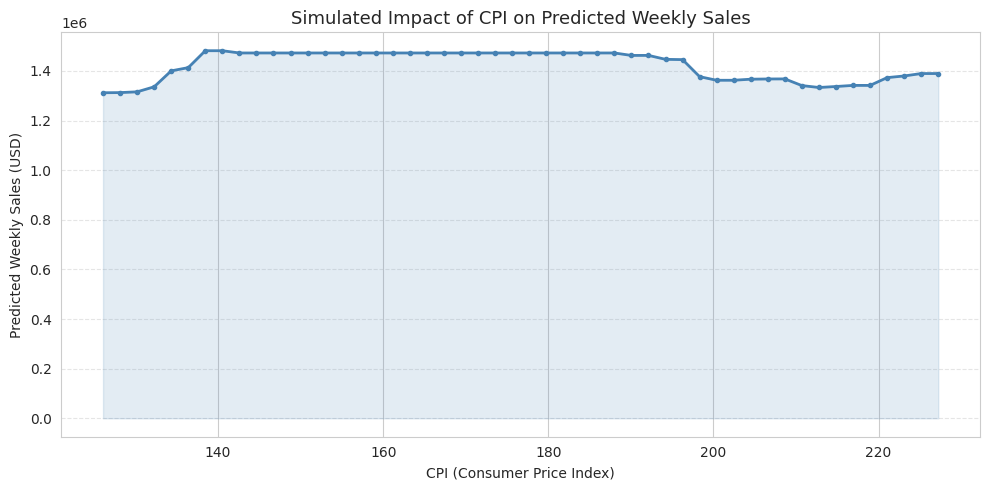

Business Insight: As CPI varies from 126.06 to 227.23,
the predicted Weekly Sales range from $1,312,173 to $1,481,571.


In [ ]:
# Simulating the impact of CPI on predicted Weekly Sales

# Select a range for CPI (using scaled values for prediction, and inverse for display)
cpi_scaled_min = df_encoded['CPI'].min()
cpi_scaled_max = df_encoded['CPI'].max()
cpi_scaled_range = np.linspace(cpi_scaled_min, cpi_scaled_max, 50)

# Get the original CPI min and max for axis labeling
original_cpi_col_index = scale_cols.index('CPI')
original_cpi_min = scaler.inverse_transform([[0,0,cpi_scaled_min,0]])[0, original_cpi_col_index]
original_cpi_max = scaler.inverse_transform([[0,0,cpi_scaled_max,0]])[0, original_cpi_col_index]
original_cpi_values_for_plot = np.linspace(original_cpi_min, original_cpi_max, 50)

# Choose a baseline row from the test set for simulation
# We need to ensure all other features remain constant and scaled correctly
base_row_scaled = X_test.iloc[0:1].copy()

simulated_sales = []
for scaled_cpi_val in cpi_scaled_range:
    temp_row = base_row_scaled.copy()

    # Modify the CPI value in the scaled base row
    # Find the column index for 'CPI' in the scaled features
    cpi_feature_col_name = 'CPI' # In df_encoded, it's just 'CPI'
    temp_row[cpi_feature_col_name] = scaled_cpi_val

    # Predict using the best Random Forest model
    pred = best_rf.predict(temp_row)
    simulated_sales.append(pred[0])

plt.figure(figsize=(10, 5))
plt.plot(original_cpi_values_for_plot, simulated_sales, color='steelblue', linewidth=2, marker='o', markersize=3)
plt.fill_between(original_cpi_values_for_plot, simulated_sales, alpha=0.15, color='steelblue')
plt.title('Simulated Impact of CPI on Predicted Weekly Sales', fontsize=13)
plt.xlabel('CPI (Consumer Price Index)')
plt.ylabel('Predicted Weekly Sales (USD)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Business Insight: As CPI varies from {original_cpi_min:.2f} to {original_cpi_max:.2f},")
print(f"the predicted Weekly Sales range from ${min(simulated_sales):,.0f} to ${max(simulated_sales):,.0f}.")



---

### 9. Final Summary


In [ ]:
best_model = results_df.loc[results_df['R2'].idxmax()]

print("Final model selected based on highest R² and lowest error metrics\n")
print("╔══════════════════════════════════════════════════════════╗")
print("║      MIS444 — Walmart Weekly Sales Prediction Summary    ║")
print("╠══════════════════════════════════════════════════════════╣")
print(f"║  Dataset          : {df.shape[0]:,} records, {df.shape[1]} features           ║")
print(f"║  Problem Type     : Regression                           ║")
print(f"║  Models Trained   : {len(models)} ({', '.join(models.keys())})                   ║")
print(f"║  Models Optimized : 1 (Random Forest via GridSearchCV)          ║")
print("╠══════════════════════════════════════════════════════════╣")
print(f"║  Best Model       : {best_model['Model']:<37s}║")
print(f"║  Best R²          : {best_model['R2']:.4f}{' '*30}║")
print(f"║  Best MAE         : ${best_model['MAE']:>10,.2f} USD{' '*22}║")
print(f"║  Best MAPE        : {best_model['MAPE']:.4f}{' '*30}║")
print(f"║  Best RMSE        :${best_model['RMSE']:>10,.2f} USD{' '*22}║")
print("╚══════════════════════════════════════════════════════════╝")

print("\nFinal Conclusion")
print("This project successfully applied predictive analytics techniques to estimate Walmart Weekly Sales using multiple regression models.")
print("\nAmong all models, the Linear Regression model performed the best, achieving the highest accuracy and lowest prediction error.")
print("\nThe model can be used by businesses for sales forecasting, inventory management, marketing strategy, and resource allocation.")
print("\nFuture improvements include incorporating more granular daily sales data, additional local economic indicators, competitor activities, and advanced time-series analysis methods to enhance model generalizability and accuracy.")

Final model selected based on highest R² and lowest error metrics

╔══════════════════════════════════════════════════════════╗
║      MIS444 — Walmart Weekly Sales Prediction Summary    ║
╠══════════════════════════════════════════════════════════╣
║  Dataset          : 6,435 records, 12 features           ║
║  Problem Type     : Regression                           ║
║  Models Trained   : 5 (Linear Regression, Ridge Regression, Decision Tree, Random Forest, Gradient Boosting)                   ║
║  Models Optimized : 1 (Random Forest via GridSearchCV)          ║
╠══════════════════════════════════════════════════════════╣
║  Best Model       : Linear Regression                    ║
║  Best R²          : 0.9519                              ║
║  Best MAE         : $ 84,398.27 USD                      ║
║  Best MAPE        : 0.0958                              ║
║  Best RMSE        :$117,055.76 USD                      ║
╚══════════════════════════════════════════════════════════╝

Fina